In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# 1. Define standard normalization for the ResNet-18 model
# Note: We resize to 32x32 for the model, but we'll need to scale ROI accordingly
data_transforms = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
])

# 2. Load the Dataset
# root='./data' will download it to your Colab environment
train_dataset = datasets.GTSRB(root='./data', split='train', download=True, transform=data_transforms)
test_dataset = datasets.GTSRB(root='./data', split='test', download=True, transform=data_transforms)



100%|██████████| 187M/187M [00:17<00:00, 10.5MB/s]
100%|██████████| 89.0M/89.0M [00:06<00:00, 14.8MB/s]
100%|██████████| 99.6k/99.6k [00:00<00:00, 183kB/s]


In [ ]:


train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [ ]:
def get_roi_mask(dataset, index, target_size=(32, 32)):
    # 1. Get the raw metadata for this specific sample
    # sample structure: (path, label, width, height, x1, y1, x2, y2)
    _, _, width, height, x1, y1, x2, y2 = dataset._samples[index]

    # 2. Calculate scaling factors
    scale_x = target_size[0] / width
    scale_y = target_size[1] / height

    # 3. Scale coordinates to the 32x32 space
    nx1, ny1 = int(x1 * scale_x), int(y1 * scale_y)
    nx2, ny2 = int(x2 * scale_x), int(y2 * scale_y)

    # 4. Create the binary mask (1 inside ROI, 0 outside)
    mask = torch.zeros((1, target_size[1], target_size[0]))
    mask[:, ny1:ny2, nx1:nx2] = 1.0

    return mask, (nx1, ny1, nx2, ny2)

In [ ]:
import pandas as pd
import pathlib

def get_roi_mask_fixed(dataset, index, target_size=(32, 32)):
    # 1. Get the path and label from the dataset
    img_path, label = dataset._samples[index]
    img_path = pathlib.Path(img_path)

    # 2. Locate the CSV for this specific class (Train split)
    # The CSV is usually in the same folder as the images: GT-<class_id>.csv
    csv_path = img_path.parent / f"GT-{label:05d}.csv"

    # 3. Read the ROI from the CSV
    # GTSRB CSVs use ';' as a delimiter
    df = pd.read_csv(csv_path, sep=';')
    filename = img_path.name
    row = df[df['Filename'] == filename].iloc[0]

    width, height = row['Width'], row['Height']
    x1, y1, x2, y2 = row['Roi.X1'], row['Roi.Y1'], row['Roi.X2'], row['Roi.Y2']

    # 4. Scale to 32x32
    scale_x = target_size[0] / width
    scale_y = target_size[1] / height

    nx1, ny1 = int(x1 * scale_x), int(y1 * scale_y)
    nx2, ny2 = int(x2 * scale_x), int(y2 * scale_y)

    mask = torch.zeros((1, target_size[1], target_size[0]))
    mask[:, ny1:ny2, nx1:nx2] = 1.0

    return mask, (nx1, ny1, nx2, ny2)

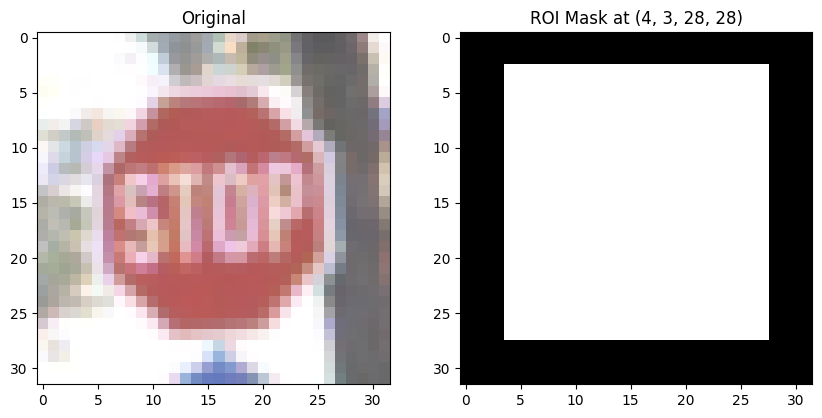

In [ ]:
# Updated Sanity Check
idx = 15
for i, (_, label) in enumerate(train_dataset):
    if label == 14: # Stop Sign
        idx = i
        break

img, _ = train_dataset[idx]
mask, coords = get_roi_mask_fixed(train_dataset, idx)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img.permute(1, 2, 0))
plt.title("Original")

plt.subplot(1, 2, 2)
plt.imshow(mask.squeeze(), cmap='gray')
plt.title(f"ROI Mask at {coords}")
plt.show()

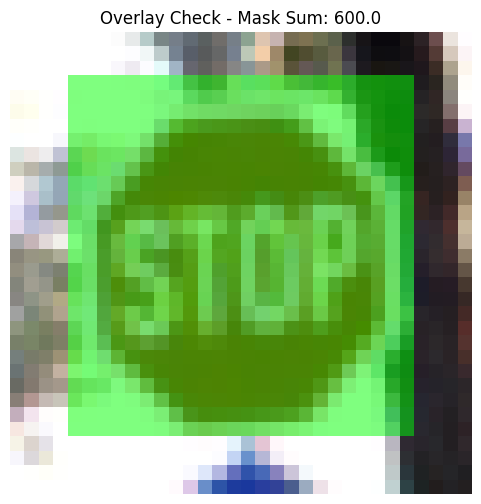

In [ ]:
def visualize_overlay_fixed(image_tensor, mask_tensor):
    # 1. Convert to numpy and ensure ranges are [0, 1]
    img = image_tensor.permute(1, 2, 0).cpu().numpy()
    img = (img - img.min()) / (img.max() - img.min()) # Normalize for display

    mask = mask_tensor.squeeze().cpu().numpy()

    # 2. Create a Green overlay (Green is often easier to see against red signs)
    # We create a 3-channel overlay
    colored_mask = np.zeros_like(img)
    colored_mask[..., 1] = 1.0  # Set Green channel to max

    # 3. Blending
    # Result = (1 - alpha) * Image + alpha * Colored_Mask
    alpha = 0.5
    # Apply alpha ONLY where mask is 1
    blended = np.where(mask[..., None] > 0,
                       (1 - alpha) * img + alpha * colored_mask,
                       img)

    plt.figure(figsize=(6, 6))
    plt.imshow(blended)
    plt.title(f"Overlay Check - Mask Sum: {mask.sum()}") # Sum should be < 1024
    plt.axis('off')
    plt.show()

visualize_overlay_fixed(img, mask)

In [ ]:
def create_sticker_mask(roi_mask, sticker_size=(10, 10)):
    # 1. Find the center of the ROI mask
    coords = torch.nonzero(roi_mask.squeeze())
    y_min, x_min = coords.min(dim=0).values
    y_max, x_max = coords.max(dim=0).values

    center_y, center_x = (y_min + y_max) // 2, (x_min + x_max) // 2

    # 2. Create a 10x10 square around that center
    half_s = sticker_size[0] // 2
    s_mask = torch.zeros_like(roi_mask)
    s_mask[:, center_y-half_s : center_y+half_s,
              center_x-half_s : center_x+half_s] = 1.0

    return s_mask

# Generate the actual sticker area
sticker_mask = create_sticker_mask(mask)

In [ ]:
sticker_mask

tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]])

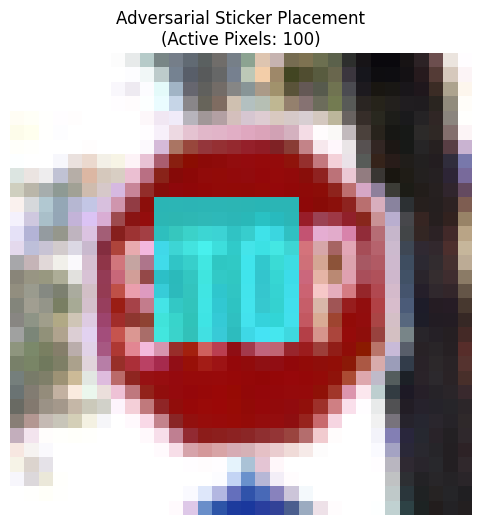

In [ ]:
def visualize_sticker_on_sign(image_tensor, sticker_mask):
    # 1. Prepare image (Normalize to [0, 1] for display)
    img_np = image_tensor.permute(1, 2, 0).cpu().detach().numpy()
    img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())

    # 2. Prepare the sticker mask
    s_mask = sticker_mask.squeeze().cpu().detach().numpy()

    # 3. Create a Cyan overlay [0, 1, 1] for the sticker area
    cyan_overlay = np.zeros_like(img_np)
    cyan_overlay[..., 1] = 1.0 # Green channel
    cyan_overlay[..., 2] = 1.0 # Blue channel

    # 4. Blend the image with the sticker mask
    alpha = 0.7  # High visibility for the sticker area
    blended = np.where(s_mask[..., None] > 0,
                       (1 - alpha) * img_np + alpha * cyan_overlay,
                       img_np)

    plt.figure(figsize=(6, 6))
    plt.imshow(blended)
    plt.title(f"Adversarial Sticker Placement\n(Active Pixels: {int(s_mask.sum())})")
    plt.axis('off')
    plt.show()

# Visualize the $10 \times 10$ sticker on your image
visualize_sticker_on_sign(img, sticker_mask)

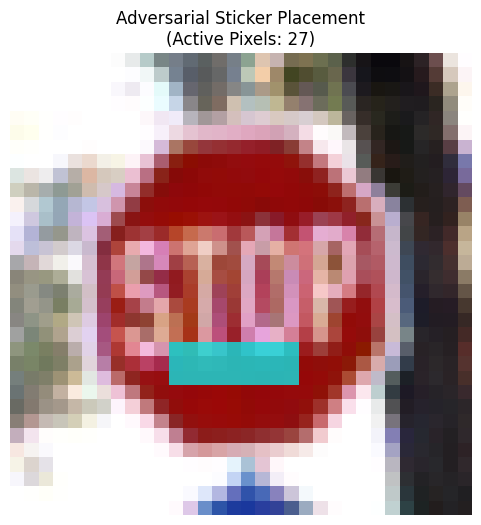

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
def create_low_rectangular_mask(roi_mask, rect_size=(2, 8)):
    coords = torch.nonzero(roi_mask.squeeze())
    y_min, x_min = coords.min(dim=0).values
    y_max, x_max = coords.max(dim=0).values

    # Position it lower (shifting y further down)
    # Using +5 or +6 moves it toward the bottom edge of the 'STOP' text
    center_y = (y_min + y_max) // 2 + 6
    center_x = (x_min + x_max) // 2

    h, w = rect_size
    s_mask = torch.zeros_like(roi_mask).to(device)
    s_mask[:, center_y - h//2 : center_y + h//2 + 1,
              center_x - w//2 : center_x + w//2 + 1] = 1.0

    return s_mask

# Generate and verify one last time
tape_mask = create_low_rectangular_mask(mask, rect_size=(2,8))
visualize_sticker_on_sign(img, tape_mask)

In [ ]:
import torch.nn.functional as F
import torchvision.transforms.functional as TF
import random
from torchvision import datasets, transforms, models
# 1. Initialize the Universal Patch (the 3x10 'tape')
# We'll create a full 32x32 tensor but only gradients in the mask area will matter
patch = torch.full((3, 32, 32), 0.5, device=device, requires_grad=True)
optimizer = torch.optim.Adam([patch], lr=0.01)
target_class = 5  # Speed Limit 80



def apply_eot_batch(images):
    """Applies random transformations to a batch of images."""
    transformed = []
    for img in images:
        # Random Rotation: +/- 10 degrees
        angle = random.uniform(-10, 10)
        img = TF.rotate(img, angle)

        # Random Brightness: 80% to 120%
        brightness = random.uniform(0.8, 1.2)
        img = img * brightness

        # Random Additive Noise
        noise = torch.randn_like(img) * 0.05
        img = img + noise

        transformed.append(torch.clamp(img, 0, 1))
    return torch.stack(transformed)



In [ ]:
device

device(type='cuda')

In [ ]:
import torch.nn.functional as F
import torchvision.transforms.functional as TF
from tqdm import trange
import torch.nn as nn


# Initialize the Universal Patch
patch = torch.full((3, 32, 32), 0.5, device=device, requires_grad=True)
optimizer = torch.optim.AdamW([patch], lr=0.05)
target_class = 5  # Speed Limit 80
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 43)
model.load_state_dict(torch.load('/content/gtsrb_resnet18.pth', weights_only=True))
model=model.cuda()
best_loss = float('inf')

model.eval()
for epoch in trange(100):
    total_loss = 0
    for i, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        optimizer.zero_grad()

        # 1. GENERATE DYNAMIC MASKS FOR THE BATCH
        # We create a combined mask for the whole batch
        batch_masks = []
        for idx in range(images.size(0)):
            # We use the index from the dataset to find the specific ROI
            dataset_idx = i * train_loader.batch_size + idx
            roi_mask, _ = get_roi_mask_fixed(train_dataset, dataset_idx)

            # Create the 3x10 tape at the 'low' position for THIS specific sign
            m = create_low_rectangular_mask(roi_mask, rect_size=(2, 8))
            batch_masks.append(m)

        batch_masks = torch.stack(batch_masks).to(device)

        # 2. APPLY THE PATCH
        # patched = (Image where mask is 0) + (Patch where mask is 1)
        patched_images = images * (1 - batch_masks) + patch * batch_masks

        # 3. EXPECTATION OVER TRANSFORMATION (EOT)
        eot_images = apply_eot_batch(patched_images)

        # 4. OPTIMIZE TOWARD TARGET
        outputs = model(eot_images)
        targets = torch.full((images.size(0),), target_class, device=device)
        loss = F.cross_entropy(outputs, targets)

        loss.backward()

        # IMPORTANT: Only update pixels where the mask was active
        # This keeps the 'tape' shape crisp
        with torch.no_grad():
            patch.grad.mul_(batch_masks.mean(dim=0)) # Average mask for the batch

        optimizer.step()

        with torch.no_grad():
            patch.clamp_(0, 1)

        total_loss += loss.item()

    avg_loss=total_loss/len(train_loader)

    if avg_loss < best_loss:
      best_loss = avg_loss
      # Save as a PyTorch tensor for research
      torch.save(patch, 'best_rp2_patch2.pt')

    if epoch % 10 == 0:
        print(f"Epoch {epoch} | Avg Loss: {total_loss/len(train_loader):.4f}")
        print(f"Patch Mean Value: {patch.data.mean().item():.4f}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 135MB/s]
  1%|          | 1/100 [01:51<3:03:13, 111.04s/it]

Epoch 0 | Avg Loss: 3.8331
Patch Mean Value: 0.4102


 11%|█         | 11/100 [20:03<2:42:32, 109.58s/it]

Epoch 10 | Avg Loss: 3.5080
Patch Mean Value: 0.0766


...

Epoch 40 | Avg Loss: 3.4918
Patch Mean Value: 0.0291


 51%|█████     | 51/100 [1:34:14<1:30:34, 110.91s/it]

Epoch 50 | Avg Loss: 3.4655
Patch Mean Value: 0.0298


 52%|█████▏    | 52/100 [1:37:31<1:30:01, 112.54s/it]


KeyboardInterrupt: 

In [ ]:
torch.save(patch, 'rp2_tape_patch.pt')

In [ ]:
patch

tensor([[[0.5000, 0.5000, 0.5000,  ..., 0.5000, 0.5000, 0.5000],
         [0.5000, 0.5000, 0.5000,  ..., 0.5000, 0.5000, 0.5000],
         [0.5000, 0.5000, 0.5000,  ..., 0.5000, 0.5000, 0.5000],
         ...,
         [0.5000, 0.5000, 0.5000,  ..., 0.5000, 0.5000, 0.5000],
         [0.5000, 0.5000, 0.5000,  ..., 0.5000, 0.5000, 0.5000],
         [0.5000, 0.5000, 0.5000,  ..., 0.5000, 0.5000, 0.5000]],

        [[0.5000, 0.5000, 0.5000,  ..., 0.5000, 0.5000, 0.5000],
         [0.5000, 0.5000, 0.5000,  ..., 0.5000, 0.5000, 0.5000],
         [0.5000, 0.5000, 0.5000,  ..., 0.5000, 0.5000, 0.5000],
         ...,
         [0.5000, 0.5000, 0.5000,  ..., 0.5000, 0.5000, 0.5000],
         [0.5000, 0.5000, 0.5000,  ..., 0.5000, 0.5000, 0.5000],
         [0.5000, 0.5000, 0.5000,  ..., 0.5000, 0.5000, 0.5000]],

        [[0.5000, 0.5000, 0.5000,  ..., 0.5000, 0.5000, 0.5000],
         [0.5000, 0.5000, 0.5000,  ..., 0.5000, 0.5000, 0.5000],
         [0.5000, 0.5000, 0.5000,  ..., 0.5000, 0.5000, 0.

In [ ]:
optimized_patch = torch.load('/content/best_rp2_patch.pt')

tensor([ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.9900, -0.3246,  0.0685, -0.0943,  0.3454, -0.1274, -0.0515,
         0.0847, -0.1630,  0.0625, -0.0090,  0.5560, -0.5665,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000],
       device='cuda:0', grad_fn=<AddBackward0>)